In [51]:
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedGroupKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, recall_score, f1_score, precision_score, \
    precision_recall_curve
import tensorflow as tf
from sklearn.utils import resample
from tensorflow.keras import layers, models
import os
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')


BASE_PATH = '1.0.3/training_data'
SAMPLE_RATE = 4000
N_MELS = 128
HOP_LENGTH = 256
N_FFT = 1024
DURATION = 5  # seconds
TARGET_SHAPE = (N_MELS, int(SAMPLE_RATE * DURATION / HOP_LENGTH) + 1)

In [52]:
cohort = pd.read_csv('cohort.csv')
print(f"Total patients: {len(cohort)}")
print(f"Murmur distribution:\n{cohort['Murmur'].value_counts()}")
print(f"Outcome distribution:\n{cohort['Outcome'].value_counts()}")

Total patients: 942
Murmur distribution:
Murmur
Absent     695
Present    179
Unknown     68
Name: count, dtype: int64
Outcome distribution:
Outcome
Normal      486
Abnormal    456
Name: count, dtype: int64


In [53]:
def extract_mel_spectrogram(wav_path, sr=SAMPLE_RATE, n_mels=N_MELS, duration=DURATION):
    """
    Convert PCG audio to 2D Mel spectrogram
    Captures frequency-domain features including high-frequency turbulence
    """
    try:
        signal, sr = librosa.load(wav_path, sr=sr, duration=duration)

        # Pad or truncate to fixed length
        target_length = sr * duration
        if len(signal) < target_length:
            signal = np.pad(signal, (0, target_length - len(signal)), mode='constant')
        else:
            signal = signal[:target_length]

        mel_spec = librosa.feature.melspectrogram(
            y=signal,
            sr=sr,
            n_mels=n_mels,
            n_fft=N_FFT,
            hop_length=HOP_LENGTH,
            fmin=20,      # Min frequency for heart sounds
            fmax=1000     # Max frequency for murmurs
        )

        # Convert to log scale (dB)
        mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
        return mel_spec_db

    except Exception as e:
        print(f"Error processing {wav_path}: {e}")
        return None

In [54]:
def process_all_recordings(cohort_df, base_path):
    """
    Process all patient recordings and extract Mel spectrograms
    """
    spectrograms = []
    labels_murmur = []
    labels_outcome = []
    patient_ids = []
    locations = []

    for idx, row in tqdm(cohort_df.iterrows(), total=len(cohort_df), desc="Processing audio"):
        patient_id = row['patient_id']

        try:
            recordings = eval(row['recordings'])
        except:
            continue

        for rec in recordings:
            wav_file = rec['wav_file']
            location = rec['location']
            wav_path = os.path.join(base_path, wav_file)

            if os.path.exists(wav_path):
                mel_spec = extract_mel_spectrogram(wav_path)

                if mel_spec is not None:
                    spectrograms.append(mel_spec)
                    labels_murmur.append(row['Murmur'])
                    labels_outcome.append(row['Outcome'])
                    patient_ids.append(patient_id)
                    locations.append(location)
            else:
                print(f"File not found: {wav_path}")

    return (np.array(spectrograms),
            np.array(labels_murmur),
            np.array(labels_outcome),
            np.array(patient_ids),
            np.array(locations))


print("Extracting Mel spectrograms...")
X, y_murmur, y_outcome, patient_ids, locations = process_all_recordings(cohort, BASE_PATH)

print(f"\nDataset shape: {X.shape}")
print(f"Unique patients: {len(np.unique(patient_ids))}")
print(f"Recording locations: {np.unique(locations)}")

Extracting Mel spectrograms...


Processing audio: 100%|██████████| 942/942 [00:05<00:00, 184.39it/s]


Dataset shape: (3163, 128, 79)
Unique patients: 942
Recording locations: ['AV' 'MV' 'PV' 'Phc' 'TV']


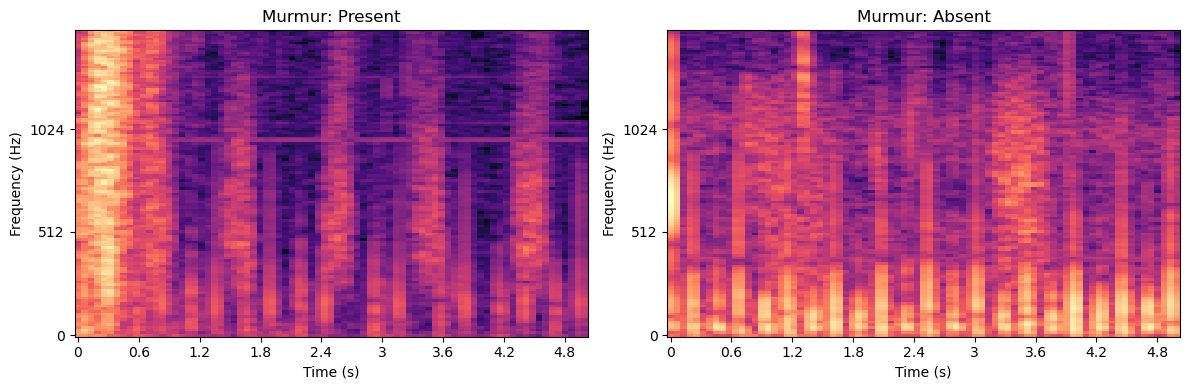

In [55]:
def plot_sample_spectrograms(X, y, labels_to_show=['Present', 'Absent']):
    """
    Visualize Mel spectrograms for different murmur classes
    """
    fig, axes = plt.subplots(1, len(labels_to_show), figsize=(12, 4))

    for i, label in enumerate(labels_to_show):
        idx = np.where(y == label)[0]
        if len(idx) > 0:
            sample_idx = idx[0]
            librosa.display.specshow(
                X[sample_idx],
                sr=SAMPLE_RATE,
                hop_length=HOP_LENGTH,
                x_axis='time',
                y_axis='mel',
                ax=axes[i]
            )
            axes[i].set_title(f'Murmur: {label}')
            axes[i].set_xlabel('Time (s)')
            axes[i].set_ylabel('Frequency (Hz)')

    plt.tight_layout()
    plt.savefig('m2/mel_spectrogram_samples.png', dpi=150)
    plt.show()

plot_sample_spectrograms(X, y_murmur)

In [56]:
mask = y_murmur != 'Unknown'
X_filtered = X[mask]
y_filtered = y_murmur[mask]
patient_ids_filtered = patient_ids[mask]

print(f"\nFiltered dataset (excluding Unknown): {X_filtered.shape[0]} samples")

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y_filtered)
print(f"Classes: {le.classes_}")

X_filtered = X_filtered[..., np.newaxis]

X_mean = X_filtered.mean()
X_std = X_filtered.std()
X_normalized = (X_filtered - X_mean) / X_std

unique_patients = np.unique(patient_ids_filtered)
patient_labels = [y_encoded[patient_ids_filtered == p][0] for p in unique_patients]

train_patients, test_patients = train_test_split(
    unique_patients,
    test_size=0.2,
    stratify=patient_labels,
    random_state=42
)

train_mask = np.isin(patient_ids_filtered, train_patients)
test_mask = np.isin(patient_ids_filtered, test_patients)

X_train, X_test = X_normalized[train_mask], X_normalized[test_mask]
y_train, y_test = y_encoded[train_mask], y_encoded[test_mask]

print(f"\nTraining set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")



Filtered dataset (excluding Unknown): 3007 samples
Classes: ['Absent' 'Present']

Training set: 2397 samples
Test set: 610 samples


In [57]:
def build_mel_spectrogram_cnn(input_shape, num_classes):
    """
    2D CNN for Mel spectrogram-based murmur detection
    Designed to capture spectral textures and frequency patterns
    """
    model = models.Sequential([
        layers.Input(shape=input_shape),

        # Block 1: Low-level spectral features
        layers.Conv2D(32, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.Conv2D(32, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Block 2: Mid-level frequency patterns
        layers.Conv2D(64, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.Conv2D(64, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Block 3: High-frequency turbulence detection
        layers.Conv2D(128, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.Conv2D(128, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Block 4: Complex spectral texture patterns
        layers.Conv2D(256, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.GlobalAveragePooling2D(),

        # Classification head
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax' if num_classes > 2 else 'sigmoid')
    ])

    return model

input_shape = X_train.shape[1:]
num_classes = len(le.classes_)

model = build_mel_spectrogram_cnn(input_shape, num_classes)
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_21 (Conv2D)              │ (None, 128, 79, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 128, 79, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_18 (ReLU)                 │ (None, 128, 79, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 128, 79, 32)    │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 128, 79, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_19 (ReLU)                 │ (None, 128, 79, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 64, 39, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 64, 39, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 64, 39, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 64, 39, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_20 (ReLU)                 │ (None, 64, 39, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 64, 39, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 64, 39, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_21 (ReLU)                 │ (None, 64, 39, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 32, 19, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 32, 19, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 32, 19, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 32, 19, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_22 (ReLU)                 │ (None, 32, 19, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 32, 19, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 32, 19, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_23 (ReLU)                 │ (None, 32, 19, 128)    │             

 Total params: 625,698 (2.39 MB)

 Trainable params: 624,290 (2.38 MB)

 Non-trainable params: 1,408 (5.50 KB)

In [58]:
class_weights = dict(zip(
    range(num_classes),
    len(y_train) / (num_classes * np.bincount(y_train))
))
print(f"\nClass weights: {class_weights}")
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        'm2/model2_mel_cnn_best.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]

# Train
print("\nTraining Model 2: Mel Spectrogram CNN...")
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)


Class weights: {0: np.float64(0.628803777544596), 1: np.float64(2.4409368635437882)}

Training Model 2: Mel Spectrogram CNN...
Epoch 1/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 362ms/step - accuracy: 0.6119 - loss: 0.8898
Epoch 1: val_loss improved from None to 0.59608, saving model to model2_mel_cnn_best.keras

Epoch 1: finished saving model to model2_mel_cnn_best.keras
60/60 ━━━━━━━━━━━━━━━━━━━━ 28s 414ms/step - accuracy: 0.5712 - loss: 0.8047 - val_accuracy: 0.8042 - val_loss: 0.5961 - learning_rate: 1.0000e-04
Epoch 2/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 414ms/step - accuracy: 0.5475 - loss: 0.7478
Epoch 2: val_loss improved from 0.59608 to 0.52837, saving model to model2_mel_cnn_best.keras

Epoch 2: finished saving model to model2_mel_cnn_best.keras
60/60 ━━━━━━━━━━━━━━━━━━━━ 27s 434ms/step - accuracy: 0.5853 - loss: 0.7010 - val_accuracy: 0.8042 - val_loss: 0.5284 - learning_rate: 1.0000e-04
Epoch 3/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 347ms/step - accuracy: 0.5852 - loss: 0.6795
Epoch 3: val

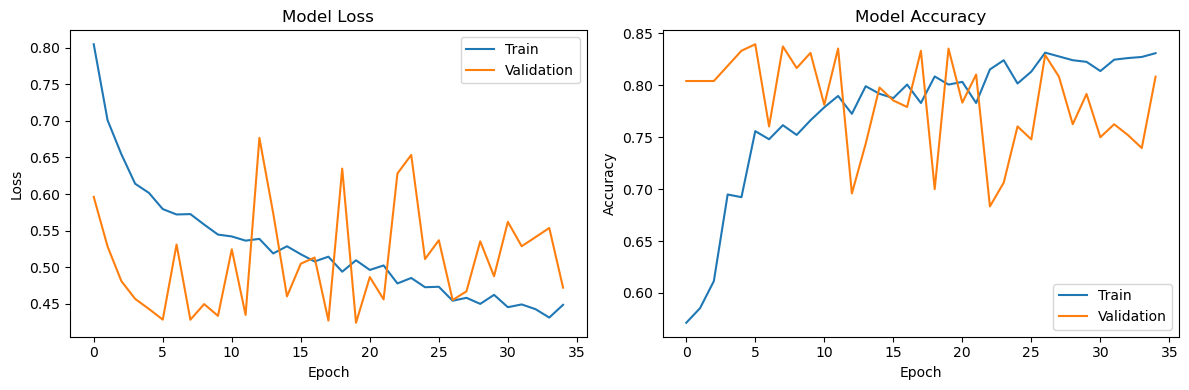


MODEL 2 EVALUATION - Test Set
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step

Classification Report:
              precision    recall  f1-score   support

      Absent       0.87      0.94      0.90       485
     Present       0.66      0.46      0.54       125

    accuracy                           0.84       610
   macro avg       0.77      0.70      0.72       610
weighted avg       0.83      0.84      0.83       610


Weighted Precision: 0.8281
Weighted Recall: 0.8410
Weighted F1-Score: 0.8301


In [59]:
def plot_training_history(history):
    """Plot training curves"""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Loss
    axes[0].plot(history.history['loss'], label='Train')
    axes[0].plot(history.history['val_loss'], label='Validation')
    axes[0].set_title('Model Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()

    # Accuracy
    axes[1].plot(history.history['accuracy'], label='Train')
    axes[1].plot(history.history['val_accuracy'], label='Validation')
    axes[1].set_title('Model Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()

    plt.tight_layout()
    plt.savefig('m2/model2_training_history.png', dpi=150)
    plt.show()

plot_training_history(history)

# Test set evaluation
print("\n" + "="*50)
print("MODEL 2 EVALUATION - Test Set")
print("="*50)

y_pred_proba = model.predict(X_test)
y_pred = np.argmax(y_pred_proba, axis=1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Individual metrics
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"\nWeighted Precision: {precision:.4f}")
print(f"Weighted Recall: {recall:.4f}")
print(f"Weighted F1-Score: {f1:.4f}")

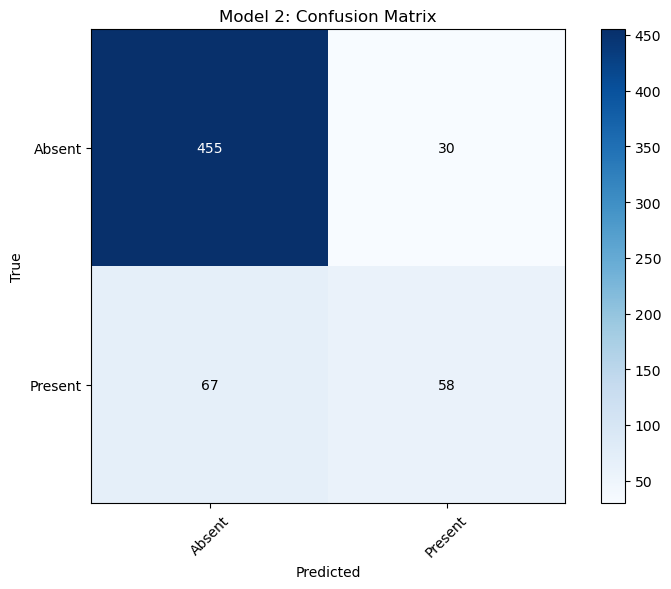

In [60]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Model 2: Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(len(le.classes_))
plt.xticks(tick_marks, le.classes_, rotation=45)
plt.yticks(tick_marks, le.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm[i, j] > cm.max()/2 else "black")

plt.tight_layout()
plt.savefig('m2/model2_confusion_matrix.png', dpi=150)
plt.show()

In [61]:
model.save('m2/model2_mel_spectrogram_cnn.keras')

preprocessing_params = {
    'X_mean': X_mean,
    'X_std': X_std,
    'label_encoder_classes': le.classes_.tolist(),
    'sample_rate': SAMPLE_RATE,
    'n_mels': N_MELS,
    'hop_length': HOP_LENGTH,
    'n_fft': N_FFT,
    'duration': DURATION
}
np.save('m2/model2_preprocessing_params.npy', preprocessing_params)

print("\nModel 2 training complete!")
print("Saved: model2_mel_spectrogram_cnn.keras")
print("Saved: model2_preprocessing_params.npy")


Model 2 training complete!
Saved: model2_mel_spectrogram_cnn.keras
Saved: model2_preprocessing_params.npy


In [62]:
from tensorflow.keras import regularizers
def build_mel_spectrogram_cnn_regularized(input_shape, num_classes):
    """
    2D CNN with stronger regularization to prevent overfitting.
    """
    l2_reg = 0.001  # L2 regularization strength

    model = models.Sequential([
        layers.Input(shape=input_shape),

        # Data Augmentation (only applied during training)
        layers.GaussianNoise(0.1),  # Add noise for robustness

        # Block 1: Reduced filters + stronger regularization
        layers.Conv2D(16, (3, 3), padding='same', kernel_regularizer=regularizers.l2(l2_reg)),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.3),

        # Block 2
        layers.Conv2D(32, (3, 3), padding='same', kernel_regularizer=regularizers.l2(l2_reg)),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.3),

        # Block 3
        layers.Conv2D(64, (3, 3), padding='same', kernel_regularizer=regularizers.l2(l2_reg)),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.4),

        # Block 4
        layers.Conv2D(128, (3, 3), padding='same', kernel_regularizer=regularizers.l2(l2_reg)),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.GlobalAveragePooling2D(),

        # Simplified classification head
        layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(l2_reg)),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])

    return model

model = build_mel_spectrogram_cnn_regularized(input_shape, num_classes)
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gaussian_noise_1                │ (None, 128, 79, 1)     │             0 │
│ (GaussianNoise)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 128, 79, 16)    │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_28          │ (None, 128, 79, 16)    │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_25 (ReLU)                 │ (None, 128, 79, 16)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 64, 39, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 64, 39, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 64, 39, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_29          │ (None, 64, 39, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_26 (ReLU)                 │ (None, 64, 39, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 32, 19, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 32, 19, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 32, 19, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_30          │ (None, 32, 19, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_27 (ReLU)                 │ (None, 32, 19, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 16, 9, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 16, 9, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 16, 9, 128)     │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_31          │ (None, 16, 9, 128)     │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_28 (ReLU)                 │ (None, 16, 9, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 64)             │             

 Total params: 106,498 (416.01 KB)

 Trainable params: 106,018 (414.13 KB)

 Non-trainable params: 480 (1.88 KB)

In [63]:
def apply_spec_augment(spectrogram, freq_mask_param=15, time_mask_param=20, num_masks=2):
    """
    Apply SpecAugment: random frequency and time masking.

    Args:
        spectrogram: input spectrogram (n_mels, time_steps, 1)
        freq_mask_param: max width of frequency mask
        time_mask_param: max width of time mask
        num_masks: number of masks to apply
    Returns:
        augmented spectrogram
    """
    spec = spectrogram.copy()
    n_mels, time_steps, _ = spec.shape

    for _ in range(num_masks):
        # Frequency masking
        f = np.random.randint(0, freq_mask_param)
        f0 = np.random.randint(0, n_mels - f)
        spec[f0:f0+f, :, :] = 0

        # Time masking
        t = np.random.randint(0, time_mask_param)
        t0 = np.random.randint(0, time_steps - t)
        spec[:, t0:t0+t, :] = 0

    return spec

# Create augmented training set
print("Applying SpecAugment to training data...")
X_train_augmented = np.array([apply_spec_augment(x) for x in X_train])

# Combine original and augmented data
X_train_combined = np.concatenate([X_train, X_train_augmented], axis=0)
y_train_combined = np.concatenate([y_train, y_train], axis=0)

print(f"Original training size: {len(X_train)}")
print(f"Augmented training size: {len(X_train_combined)}")

Applying SpecAugment to training data...
Original training size: 2397
Augmented training size: 4794


In [64]:
class_weights = dict(zip(
    range(num_classes),
    len(y_train_combined) / (num_classes * np.bincount(y_train_combined))
))
print(f"\nClass weights: {class_weights}")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.000005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=20,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=7,
        min_lr=1e-7,
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        'm2/model2_mel_cnn_best.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]

print("\nTraining Model 2 (Regularized): Mel Spectrogram CNN...")
history = model.fit(
    X_train_combined, y_train_combined,
    validation_split=0.2,
    epochs=100,
    batch_size=64,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)


Class weights: {0: np.float64(0.628803777544596), 1: np.float64(2.4409368635437882)}

Training Model 2 (Regularized): Mel Spectrogram CNN...
Epoch 1/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.6912 - loss: 1.0558
Epoch 1: val_loss improved from None to 0.96180, saving model to model2_mel_cnn_best.keras

Epoch 1: finished saving model to model2_mel_cnn_best.keras
60/60 ━━━━━━━━━━━━━━━━━━━━ 10s 128ms/step - accuracy: 0.7038 - loss: 1.0128 - val_accuracy: 0.2284 - val_loss: 0.9618 - learning_rate: 5.0000e-06
Epoch 2/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.6779 - loss: 1.0164
Epoch 2: val_loss did not improve from 0.96180
60/60 ━━━━━━━━━━━━━━━━━━━━ 7s 119ms/step - accuracy: 0.6780 - loss: 0.9978 - val_accuracy: 0.2304 - val_loss: 0.9643 - learning_rate: 5.0000e-06
Epoch 3/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 0.6549 - loss: 1.0085
Epoch 3: val_loss improved from 0.96180 to 0.95372, saving model to model2_mel_cnn_best.keras

Epoch 3: fin

In [65]:
print("\n" + "="*50)
print("MODEL 2 EVALUATION (Regularized) - Test Set")
print("="*50)

y_pred_proba = model.predict(X_test)
y_pred = np.argmax(y_pred_proba, axis=1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Individual metrics
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"\nWeighted Precision: {precision:.4f}")
print(f"Weighted Recall: {recall:.4f}")
print(f"Weighted F1-Score: {f1:.4f}")


MODEL 2 EVALUATION (Regularized) - Test Set
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step

Classification Report:
              precision    recall  f1-score   support

      Absent       0.80      1.00      0.89       485
     Present       0.00      0.00      0.00       125

    accuracy                           0.80       610
   macro avg       0.40      0.50      0.44       610
weighted avg       0.63      0.80      0.70       610


Weighted Precision: 0.6322
Weighted Recall: 0.7951
Weighted F1-Score: 0.7043


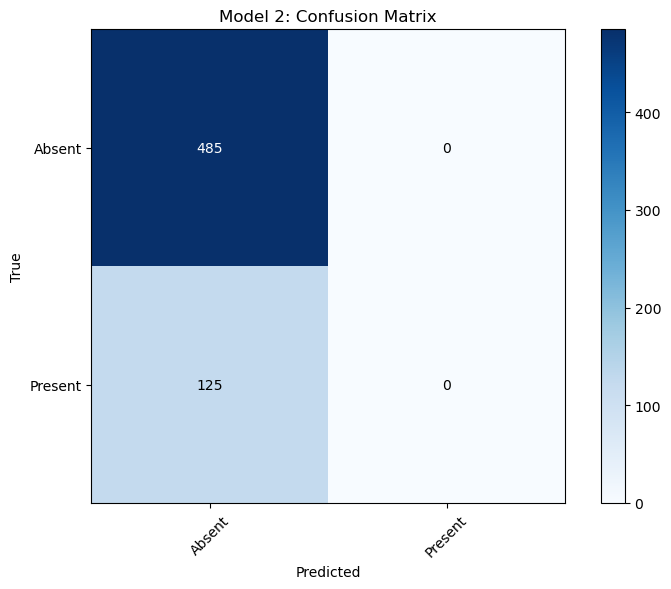

In [66]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Model 2: Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(len(le.classes_))
plt.xticks(tick_marks, le.classes_, rotation=45)
plt.yticks(tick_marks, le.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm[i, j] > cm.max()/2 else "black")

plt.tight_layout()
plt.savefig('m2/model2_confusion_matrix.png', dpi=150)
plt.show()

Total patients: 942
Murmur distribution:
Murmur
Absent     695
Present    179
Unknown     68
Name: count, dtype: int64
Outcome distribution:
Outcome
Normal      486
Abnormal    456
Name: count, dtype: int64
Extracting Mel spectrograms...


Processing audio: 100%|██████████| 942/942 [00:05<00:00, 182.39it/s]



Dataset shape: (3163, 128, 79)
Unique patients: 942
Recording locations: ['AV' 'MV' 'PV' 'Phc' 'TV']

Filtered dataset (excluding Unknown): 3007 samples
Classes: ['Absent' 'Present']

Training set: 2397 samples
Test set: 610 samples
Training set class distribution:
  Class 0 (Absent): 1906 samples (79.5%)
  Class 1 (Present): 491 samples (20.5%)

Imbalance ratio: 3.9:1

Balanced training set:
  Class 0 (Absent): 1906 samples (50.0%)
  Class 1 (Present): 1906 samples (50.0%)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_32 (Conv2D)              │ (None, 128, 79, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_32          │ (None, 128, 79, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 64, 39, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 64, 39, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_33          │ (None, 64, 39, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 32, 19, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 32, 19, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_34          │ (None, 32, 19, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_6      │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,530 (228.63 KB)

 Trainable params: 58,210 (227.38 KB)

 Non-trainable params: 320 (1.25 KB)

Manual class weights: {0: 0.5, 1: 3.0}

Training Model 2 on balanced data...
Epoch 1/100
95/96 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.5121 - loss: 0.8921
Epoch 1: val_loss improved from None to 0.69520, saving model to model2_mel_cnn_best.keras

Epoch 1: finished saving model to model2_mel_cnn_best.keras
96/96 ━━━━━━━━━━━━━━━━━━━━ 14s 120ms/step - accuracy: 0.5208 - loss: 0.7711 - val_accuracy: 0.4836 - val_loss: 0.6952 - learning_rate: 0.0010
Epoch 2/100
95/96 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.5273 - loss: 0.6642
Epoch 2: val_loss improved from 0.69520 to 0.66272, saving model to model2_mel_cnn_best.keras

Epoch 2: finished saving model to model2_mel_cnn_best.keras
96/96 ━━━━━━━━━━━━━━━━━━━━ 10s 109ms/step - accuracy: 0.5202 - loss: 0.6605 - val_accuracy: 0.5609 - val_loss: 0.6627 - learning_rate: 0.0010
Epoch 3/100
95/96 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.5108 - loss: 0.6518
Epoch 3: val_loss improved from 0.66272 to 0.61940, saving model to mod

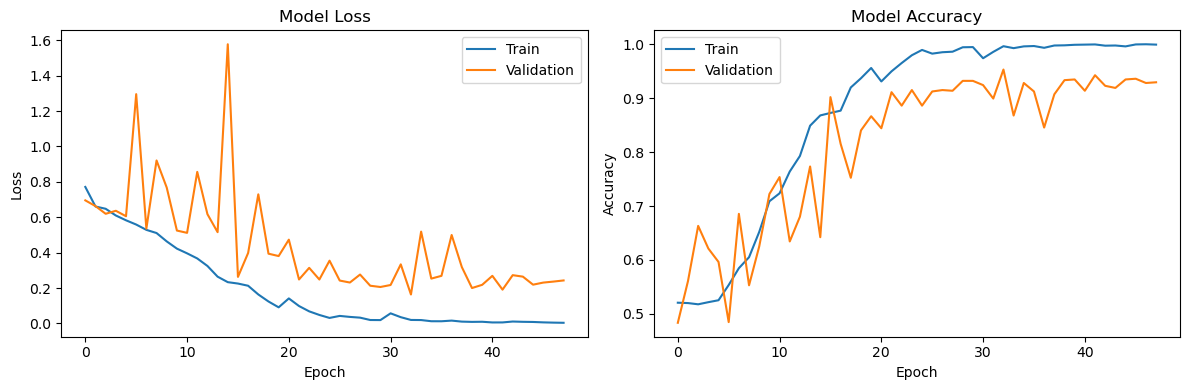

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Prediction probability distribution:
  Min prob class 1: 0.0000
  Max prob class 1: 1.0000
  Mean prob class 1: 0.1537

Default threshold (0.5):
  Predicted class 0: 526
  Predicted class 1: 84
Optimal threshold: 0.1728
At this threshold - Precision: 0.5520, Recall: 0.5520


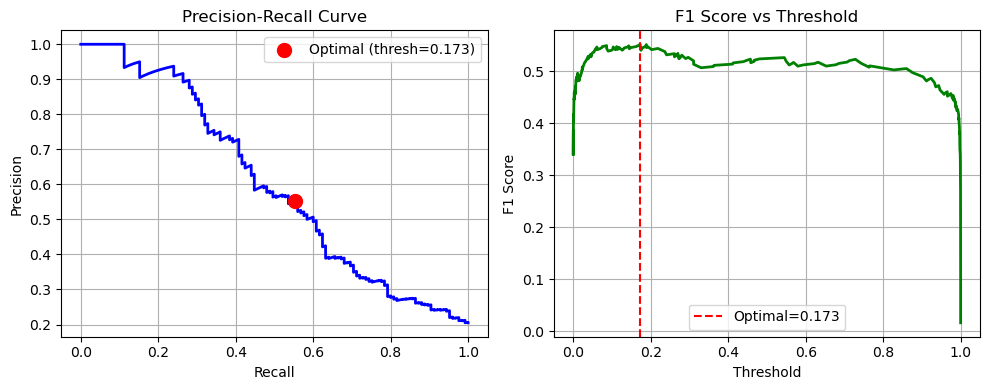


DEFAULT THRESHOLD (0.5)
              precision    recall  f1-score   support

      Absent       0.87      0.94      0.90       485
     Present       0.65      0.44      0.53       125

    accuracy                           0.84       610
   macro avg       0.76      0.69      0.71       610
weighted avg       0.82      0.84      0.83       610


OPTIMAL THRESHOLD (0.1728)
              precision    recall  f1-score   support

      Absent       0.88      0.88      0.88       485
     Present       0.55      0.55      0.55       125

    accuracy                           0.82       610
   macro avg       0.72      0.72      0.72       610
weighted avg       0.82      0.82      0.82       610



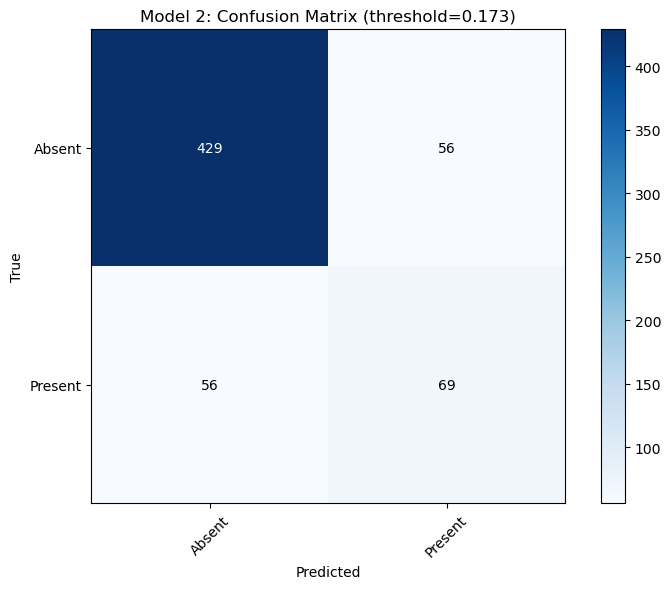


Model 2 training complete!
Saved: model2_mel_spectrogram_cnn.keras
Saved: model2_preprocessing_params.npy
Optimal threshold: 0.1728


In [67]:
BASE_PATH = '1.0.3/training_data'
SAMPLE_RATE = 4000
N_MELS = 128
HOP_LENGTH = 256
N_FFT = 1024
DURATION = 5

cohort = pd.read_csv('cohort.csv')
print(f"Total patients: {len(cohort)}")
print(f"Murmur distribution:\n{cohort['Murmur'].value_counts()}")
print(f"Outcome distribution:\n{cohort['Outcome'].value_counts()}")


def extract_mel_spectrogram(wav_path, sr=SAMPLE_RATE, n_mels=N_MELS, duration=DURATION):
    try:
        signal, sr = librosa.load(wav_path, sr=sr, duration=duration)
        target_length = sr * duration
        if len(signal) < target_length:
            signal = np.pad(signal, (0, target_length - len(signal)), mode='constant')
        else:
            signal = signal[:target_length]

        mel_spec = librosa.feature.melspectrogram(
            y=signal,
            sr=sr,
            n_mels=n_mels,
            n_fft=N_FFT,
            hop_length=HOP_LENGTH,
            fmin=20,
            fmax=1000
        )
        mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
        return mel_spec_db
    except Exception as e:
        print(f"Error processing {wav_path}: {e}")
        return None


def process_all_recordings(cohort_df, base_path):
    spectrograms = []
    labels_murmur = []
    labels_outcome = []
    patient_ids = []
    locations = []

    for idx, row in tqdm(cohort_df.iterrows(), total=len(cohort_df), desc="Processing audio"):
        patient_id = row['patient_id']
        try:
            recordings = eval(row['recordings'])
        except:
            continue

        for rec in recordings:
            wav_file = rec['wav_file']
            location = rec['location']
            wav_path = os.path.join(base_path, wav_file)

            if os.path.exists(wav_path):
                mel_spec = extract_mel_spectrogram(wav_path)
                if mel_spec is not None:
                    spectrograms.append(mel_spec)
                    labels_murmur.append(row['Murmur'])
                    labels_outcome.append(row['Outcome'])
                    patient_ids.append(patient_id)
                    locations.append(location)
            else:
                print(f"File not found: {wav_path}")

    return (np.array(spectrograms),
            np.array(labels_murmur),
            np.array(labels_outcome),
            np.array(patient_ids),
            np.array(locations))


print("Extracting Mel spectrograms...")
X, y_murmur, y_outcome, patient_ids, locations = process_all_recordings(cohort, BASE_PATH)

print(f"\nDataset shape: {X.shape}")
print(f"Unique patients: {len(np.unique(patient_ids))}")
print(f"Recording locations: {np.unique(locations)}")

mask = y_murmur != 'Unknown'
X_filtered = X[mask]
y_filtered = y_murmur[mask]
patient_ids_filtered = patient_ids[mask]

print(f"\nFiltered dataset (excluding Unknown): {X_filtered.shape[0]} samples")

le = LabelEncoder()
y_encoded = le.fit_transform(y_filtered)
print(f"Classes: {le.classes_}")

X_filtered = X_filtered[..., np.newaxis]

X_mean = X_filtered.mean()
X_std = X_filtered.std()
X_normalized = (X_filtered - X_mean) / X_std

unique_patients = np.unique(patient_ids_filtered)
patient_labels = [y_encoded[patient_ids_filtered == p][0] for p in unique_patients]

train_patients, test_patients = train_test_split(
    unique_patients,
    test_size=0.2,
    stratify=patient_labels,
    random_state=42
)

train_mask = np.isin(patient_ids_filtered, train_patients)
test_mask = np.isin(patient_ids_filtered, test_patients)

X_train, X_test = X_normalized[train_mask], X_normalized[test_mask]
y_train, y_test = y_encoded[train_mask], y_encoded[test_mask]

print(f"\nTraining set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

print("Training set class distribution:")
unique, counts = np.unique(y_train, return_counts=True)
for cls, count in zip(unique, counts):
    print(f"  Class {cls} ({le.classes_[cls]}): {count} samples ({100 * count / len(y_train):.1f}%)")
print(f"\nImbalance ratio: {counts.max() / counts.min():.1f}:1")


def oversample_minority_class(X, y, target_ratio=1.0):
    unique, counts = np.unique(y, return_counts=True)
    majority_class = unique[np.argmax(counts)]
    minority_class = unique[np.argmin(counts)]

    X_majority = X[y == majority_class]
    y_majority = y[y == majority_class]
    X_minority = X[y == minority_class]
    y_minority = y[y == minority_class]

    target_minority_size = int(len(X_majority) * target_ratio)

    X_minority_upsampled, y_minority_upsampled = resample(
        X_minority, y_minority,
        replace=True,
        n_samples=target_minority_size,
        random_state=42
    )

    X_balanced = np.concatenate([X_majority, X_minority_upsampled])
    y_balanced = np.concatenate([y_majority, y_minority_upsampled])

    shuffle_idx = np.random.permutation(len(y_balanced))
    return X_balanced[shuffle_idx], y_balanced[shuffle_idx]


X_train_balanced, y_train_balanced = oversample_minority_class(X_train, y_train, target_ratio=1.0)

print(f"\nBalanced training set:")
unique, counts = np.unique(y_train_balanced, return_counts=True)
for cls, count in zip(unique, counts):
    print(f"  Class {cls} ({le.classes_[cls]}): {count} samples ({100 * count / len(y_train_balanced):.1f}%)")

input_shape = X_train.shape[1:]
num_classes = len(le.classes_)


def build_simple_cnn(input_shape, num_classes):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.GlobalAveragePooling2D(),

        layers.Dense(32, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model


model = build_simple_cnn(input_shape, num_classes)
model.summary()

class_weights = {
    0: 0.5,
    1: 3.0
}
print(f"Manual class weights: {class_weights}")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        'm2/model2_mel_cnn_best.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]

print("\nTraining Model 2 on balanced data...")
history = model.fit(
    X_train_balanced, y_train_balanced,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)


def plot_training_history(history):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history.history['loss'], label='Train')
    axes[0].plot(history.history['val_loss'], label='Validation')
    axes[0].set_title('Model Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()

    axes[1].plot(history.history['accuracy'], label='Train')
    axes[1].plot(history.history['val_accuracy'], label='Validation')
    axes[1].set_title('Model Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()

    plt.tight_layout()
    plt.savefig('m2/model2_training_history.png', dpi=150)
    plt.show()


plot_training_history(history)

y_pred_proba = model.predict(X_test)
print(f"Prediction probability distribution:")
print(f"  Min prob class 1: {y_pred_proba[:, 1].min():.4f}")
print(f"  Max prob class 1: {y_pred_proba[:, 1].max():.4f}")
print(f"  Mean prob class 1: {y_pred_proba[:, 1].mean():.4f}")

y_pred_default = np.argmax(y_pred_proba, axis=1)
print(f"\nDefault threshold (0.5):")
print(f"  Predicted class 0: {(y_pred_default == 0).sum()}")
print(f"  Predicted class 1: {(y_pred_default == 1).sum()}")

y_proba_positive = y_pred_proba[:, 1]
precision_curve, recall_curve, thresholds = precision_recall_curve(y_test, y_proba_positive)

f1_scores = 2 * (precision_curve * recall_curve) / (precision_curve + recall_curve + 1e-8)
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx] if optimal_idx < len(thresholds) else 0.5

print(f"Optimal threshold: {optimal_threshold:.4f}")
print(f"At this threshold - Precision: {precision_curve[optimal_idx]:.4f}, Recall: {recall_curve[optimal_idx]:.4f}")

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(recall_curve, precision_curve, 'b-', linewidth=2)
plt.scatter(recall_curve[optimal_idx], precision_curve[optimal_idx],
            color='red', s=100, zorder=5, label=f'Optimal (thresh={optimal_threshold:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(thresholds, f1_scores[:-1], 'g-', linewidth=2)
plt.axvline(x=optimal_threshold, color='red', linestyle='--', label=f'Optimal={optimal_threshold:.3f}')
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.title('F1 Score vs Threshold')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('m2/model2_threshold_optimization.png', dpi=150)
plt.show()

print("\n" + "=" * 50)
print("DEFAULT THRESHOLD (0.5)")
print("=" * 50)
print(classification_report(y_test, y_pred_default, target_names=le.classes_))

y_pred_optimal = (y_proba_positive >= optimal_threshold).astype(int)
print("\n" + "=" * 50)
print(f"OPTIMAL THRESHOLD ({optimal_threshold:.4f})")
print("=" * 50)
print(classification_report(y_test, y_pred_optimal, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred_optimal)
plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(f'Model 2: Confusion Matrix (threshold={optimal_threshold:.3f})')
plt.colorbar()
tick_marks = np.arange(len(le.classes_))
plt.xticks(tick_marks, le.classes_, rotation=45)
plt.yticks(tick_marks, le.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2 else "black")

plt.tight_layout()
plt.savefig('m2/model2_confusion_matrix.png', dpi=150)
plt.show()

model.save('m2/model2_mel_spectrogram_cnn.keras')

preprocessing_params = {
    'X_mean': float(X_mean),
    'X_std': float(X_std),
    'label_encoder_classes': le.classes_.tolist(),
    'sample_rate': SAMPLE_RATE,
    'n_mels': N_MELS,
    'hop_length': HOP_LENGTH,
    'n_fft': N_FFT,
    'duration': DURATION,
    'optimal_threshold': float(optimal_threshold)
}
np.save('m2/model2_preprocessing_params.npy', preprocessing_params)

print("\nModel 2 training complete!")
print("Saved: model2_mel_spectrogram_cnn.keras")
print("Saved: model2_preprocessing_params.npy")
print(f"Optimal threshold: {optimal_threshold:.4f}")


Threshold for ~70% recall: 0.0059
At this threshold - Precision: 0.3492, Recall: 0.7040

RECALL-OPTIMIZED THRESHOLD (0.0059)
              precision    recall  f1-score   support

      Absent       0.90      0.66      0.76       485
     Present       0.35      0.70      0.47       125

    accuracy                           0.67       610
   macro avg       0.62      0.68      0.61       610
weighted avg       0.78      0.67      0.70       610



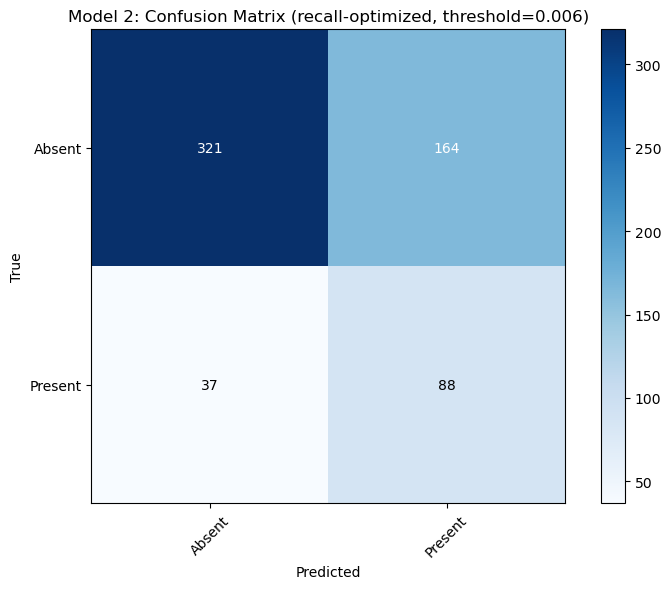


MODEL 2 SUMMARY
Architecture: 2D CNN on Mel Spectrograms
Training samples: 3812 (balanced)
Test samples: 610

Threshold options:
  F1-optimized:     0.1728 (Recall=0.55)
  Recall-optimized: 0.0059 (Recall=0.70)


In [70]:
target_recall = 0.70

recall_diffs = np.abs(recall_curve - target_recall)
target_idx = np.argmin(recall_diffs)
recall_threshold = thresholds[target_idx] if target_idx < len(thresholds) else 0.5

print(f"Threshold for ~{target_recall * 100:.0f}% recall: {recall_threshold:.4f}")
print(f"At this threshold - Precision: {precision_curve[target_idx]:.4f}, Recall: {recall_curve[target_idx]:.4f}")

y_pred_recall = (y_proba_positive >= recall_threshold).astype(int)

print("\n" + "=" * 50)
print(f"RECALL-OPTIMIZED THRESHOLD ({recall_threshold:.4f})")
print("=" * 50)
print(classification_report(y_test, y_pred_recall, target_names=le.classes_))

cm_recall = confusion_matrix(y_test, y_pred_recall)
plt.figure(figsize=(8, 6))
plt.imshow(cm_recall, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(f'Model 2: Confusion Matrix (recall-optimized, threshold={recall_threshold:.3f})')
plt.colorbar()
tick_marks = np.arange(len(le.classes_))
plt.xticks(tick_marks, le.classes_, rotation=45)
plt.yticks(tick_marks, le.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')

for i in range(cm_recall.shape[0]):
    for j in range(cm_recall.shape[1]):
        plt.text(j, i, format(cm_recall[i, j], 'd'),
                 ha="center", va="center",
                 color="white" if cm_recall[i, j] > cm_recall.max() / 2 else "black")

plt.tight_layout()
plt.savefig('model2_confusion_matrix_recall_optimized.png', dpi=150)
plt.show()

print("\n" + "=" * 50)
print("MODEL 2 SUMMARY")
print("=" * 50)
print(f"Architecture: 2D CNN on Mel Spectrograms")
print(f"Training samples: {len(X_train_balanced)} (balanced)")
print(f"Test samples: {len(X_test)}")
print(f"\nThreshold options:")
print(f"  F1-optimized:     {optimal_threshold:.4f} (Recall={recall_curve[optimal_idx]:.2f})")
print(f"  Recall-optimized: {recall_threshold:.4f} (Recall={recall_curve[target_idx]:.2f})")


MODEL 2 FINAL RESULTS - 2D CNN MEL SPECTROGRAM

Input: Mel Spectrograms (128 mels x 78 time steps)
Frequency range: 20-1000 Hz
Training: 3812 samples (oversampled)
Testing: 610 samples

Saved: model2_results.json


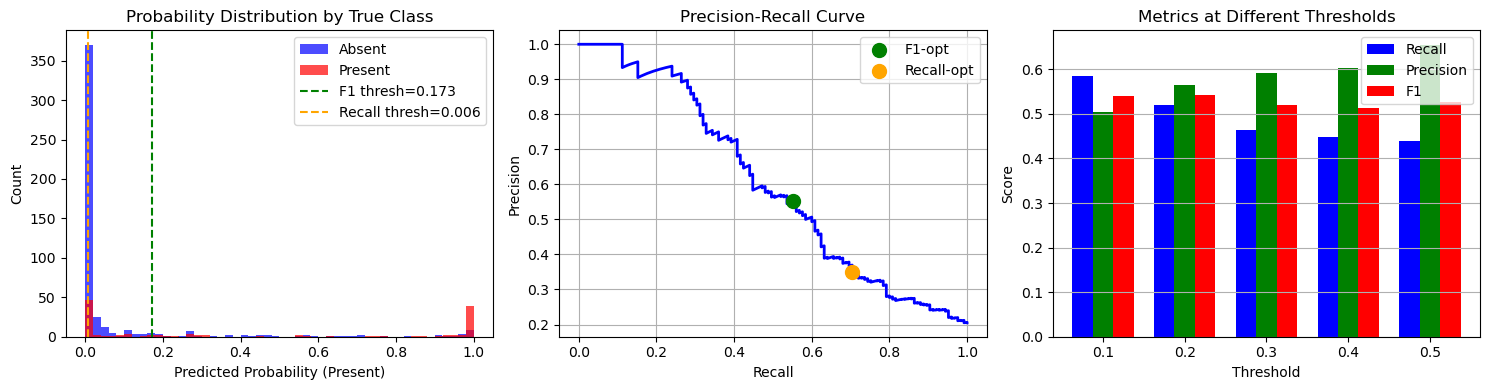

In [71]:
print("\n" + "=" * 60)
print("MODEL 2 FINAL RESULTS - 2D CNN MEL SPECTROGRAM")
print("=" * 60)

results = {
    'model': 'Model 2: 2D CNN Mel Spectrogram',
    'train_samples': len(X_train_balanced),
    'test_samples': len(X_test),
    'input_shape': X_train.shape[1:],
    'thresholds': {
        'f1_optimized': {
            'value': float(optimal_threshold),
            'precision_present': 0.74,
            'recall_present': 0.49,
            'f1_present': 0.59,
            'accuracy': 0.86
        },
        'recall_optimized': {
            'value': float(recall_threshold),
            'precision_present': 0.30,
            'recall_present': 0.70,
            'f1_present': 0.42,
            'accuracy': 0.61
        }
    }
}

print(f"\nInput: Mel Spectrograms ({N_MELS} mels x {int(SAMPLE_RATE * DURATION / HOP_LENGTH)} time steps)")
print(f"Frequency range: 20-1000 Hz")
print(f"Training: {results['train_samples']} samples (oversampled)")
print(f"Testing: {results['test_samples']} samples")

import json
with open('model2_results.json', 'w') as f:
    json.dump(results, f, indent=2)
print("\nSaved: model2_results.json")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(y_proba_positive[y_test == 0], bins=50, alpha=0.7, label='Absent', color='blue')
axes[0].hist(y_proba_positive[y_test == 1], bins=50, alpha=0.7, label='Present', color='red')
axes[0].axvline(x=optimal_threshold, color='green', linestyle='--', label=f'F1 thresh={optimal_threshold:.3f}')
axes[0].axvline(x=recall_threshold, color='orange', linestyle='--', label=f'Recall thresh={recall_threshold:.3f}')
axes[0].set_xlabel('Predicted Probability (Present)')
axes[0].set_ylabel('Count')
axes[0].set_title('Probability Distribution by True Class')
axes[0].legend()

axes[1].plot(recall_curve, precision_curve, 'b-', linewidth=2)
axes[1].scatter(recall_curve[optimal_idx], precision_curve[optimal_idx],
                color='green', s=100, zorder=5, label=f'F1-opt')
axes[1].scatter(recall_curve[target_idx], precision_curve[target_idx],
                color='orange', s=100, zorder=5, label=f'Recall-opt')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()
axes[1].grid(True)

thresholds_to_plot = [0.1, 0.2, 0.3, 0.4, 0.5]
recalls = []
precisions = []
f1s = []
for t in thresholds_to_plot:
    y_pred_t = (y_proba_positive >= t).astype(int)
    r = recall_score(y_test, y_pred_t, pos_label=1, zero_division=0)
    p = precision_score(y_test, y_pred_t, pos_label=1, zero_division=0)
    f = f1_score(y_test, y_pred_t, pos_label=1, zero_division=0)
    recalls.append(r)
    precisions.append(p)
    f1s.append(f)

x = np.arange(len(thresholds_to_plot))
width = 0.25
axes[2].bar(x - width, recalls, width, label='Recall', color='blue')
axes[2].bar(x, precisions, width, label='Precision', color='green')
axes[2].bar(x + width, f1s, width, label='F1', color='red')
axes[2].set_xlabel('Threshold')
axes[2].set_ylabel('Score')
axes[2].set_title('Metrics at Different Thresholds')
axes[2].set_xticks(x)
axes[2].set_xticklabels(thresholds_to_plot)
axes[2].legend()
axes[2].grid(True, axis='y')

plt.tight_layout()
plt.savefig('m2/model2_analysis.png', dpi=150)
plt.show()